In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
from scipy.integrate import quad

In [2]:
TIME_PATTERN = re.compile(r"imf_at_time_(\d+)_Myr\.txt$")

def read_imf_txt(file_path):
    """Parse one six-line IMF text file into numpy arrays."""
    lines = Path(file_path).read_text().splitlines()
    sections = {}
    for index in range(0, len(lines), 2):
        label = lines[index].lstrip("#").strip()
        sections[label] = np.fromstring(lines[index + 1], sep=" ")
    return sections


def load_imf_time_series(plots_dir):
    """Load and sort all imf_at_time_*_Myr.txt files from one plots directory."""
    plots_dir = Path(plots_dir)
    files = []
    for file_path in plots_dir.glob("imf_at_time_*_Myr.txt"):
        match = TIME_PATTERN.search(file_path.name)
        if match:
            files.append((int(match.group(1)), file_path))

    files.sort(key=lambda item: item[0])
    frames = []
    reference_mass = None
    reference_kroupa = None

    for time_myr, file_path in files:
        data = read_imf_txt(file_path)
        if reference_mass is None:
            reference_mass = data["mass_list"]
            reference_kroupa = data["xi_Kroupa"]
        frames.append(
            {
                "time_myr": time_myr,
                "mass_list": data["mass_list"],
                "xi_each_time": data["xi_each_time"],
                "xi_Kroupa": data["xi_Kroupa"],
                "file_path": file_path,
            }
        )

    return frames

def _positive_or_nan(values):
    masked = np.asarray(values, dtype=float).copy()
    masked[masked <= 0] = np.nan
    return masked

def kroupa_imf(mass):
    # if mass < 0.5:
    #     return 2*mass**(-1.3)
    # elif mass < 1:
    #     return mass**(-2.3)
    if mass < 0.5:
        return 1.3*mass**(-0.1)
    elif mass < 1:
        return mass**(-0.5)
    elif mass < 150:
        return mass**(-1.8)
    
def animate_imf_evolution(
    plots_dir,
    interval=700,
    figsize=(9, 6),
    xscale="log",
    yscale="log",
    ylim=None,
    repeat=True,
):
    """Animate xi_each_time and xi_Kroupa across all timesteps in one plots directory."""
    frames = load_imf_time_series(plots_dir)
    mass_list = frames[0]["mass_list"]

    xi_each_positive = [_positive_or_nan(frame["xi_each_time"]) for frame in frames]
    xi_kroupa_positive = _positive_or_nan(frames[0]["xi_Kroupa"])

    combined = np.concatenate(
        [arr[np.isfinite(arr)] for arr in [*xi_each_positive, xi_kroupa_positive] if np.isfinite(arr).any()]
    )

    auto_ylim = (combined.min() * 0.8, combined.max() * 1.2)

    plt.rc('font', family='serif')
    fig, ax = plt.subplots(figsize=figsize)
    line_each, = ax.plot([], [], color="tab:green", lw=2.2, label="IGIMF")
    line_kroupa, = ax.plot([], [], color="purple", lw=2.2, label="Kroupa IMF")
    # line_kroupa_topheavy, = ax.plot([], [], color="red", lw=2.2, label="Top-Heavy Kroupa IMF")

    ax.set_xlabel("Stellar Mass ($\\mathrm{M_{\\odot}}$)", fontsize=12)
    ax.set_ylabel("IMF ($\\mathrm{\\xi}$)", fontsize=12)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.set_xlim(mass_list.min(), mass_list.max())
    ax.set_ylim(*(ylim or auto_ylim))
    ax.legend(fontsize=11)

    def update(frame_index):
        frame = frames[frame_index]
        line_each.set_data(mass_list, _positive_or_nan(frame["xi_each_time"]))
        line_kroupa.set_data(mass_list, _positive_or_nan(frame["xi_Kroupa"]))
        # top_heavy = _positive_or_nan([kroupa_imf(m) for m in mass_list])
        # line_kroupa_topheavy.set_data(mass_list, top_heavy*1e8)
        ax.set_title(f"IGIMF evolution at {frame['time_myr']} Myr")
        return line_each, line_kroupa

    animation = FuncAnimation(
        fig,
        update,
        frames=len(frames),
        interval=interval,
        blit=False,
        repeat=repeat,
    )

    plt.close(fig)
    return animation


In [6]:
def read_imf_txt(file_path):
    """Parse one six-line IMF text file into numpy arrays."""
    lines = Path(file_path).read_text().splitlines()
    sections = {}
    for index in range(0, len(lines), 2):
        label = lines[index].lstrip("#").strip()
        sections[label] = np.fromstring(lines[index + 1], sep=" ")
    return sections

print(read_imf_txt("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/igimf/20260701/imfigimfSTF-4.15alpha3.0log_SFR<module 'igimf_SFR_-190459_Fe_over_H_25849' from '/Users/adriana_work/Desktop/galIMF/Generated_IGIMFs/igimf_SFR_-190459_Fe_over_H_25849.py'>SFEN1.2SFE0.006Z_015infall0.009/plots/imf_at_time_10_Myr.txt"))

{'mass_list': array([2.00000000e+02, 1.98000000e+02, 1.96020000e+02, 1.94059800e+02,
       1.92119202e+02, 1.90198010e+02, 1.88296030e+02, 1.86413070e+02,
       1.84548939e+02, 1.82703449e+02, 1.80876415e+02, 1.79067651e+02,
       1.77276974e+02, 1.75504205e+02, 1.73749163e+02, 1.72011671e+02,
       1.70291554e+02, 1.68588639e+02, 1.66902752e+02, 1.65233725e+02,
       1.63581388e+02, 1.61945574e+02, 1.60326118e+02, 1.58722857e+02,
       1.57135628e+02, 1.55564272e+02, 1.54008629e+02, 1.52468543e+02,
       1.50943857e+02, 1.49434419e+02, 1.47940075e+02, 1.46460674e+02,
       1.44996067e+02, 1.43546107e+02, 1.42110645e+02, 1.40689539e+02,
       1.39282644e+02, 1.37889817e+02, 1.36510919e+02, 1.35145810e+02,
       1.33794352e+02, 1.32456408e+02, 1.31131844e+02, 1.29820526e+02,
       1.28522320e+02, 1.27237097e+02, 1.25964726e+02, 1.24705079e+02,
       1.23458028e+02, 1.22223448e+02, 1.21001213e+02, 1.19791201e+02,
       1.18593289e+02, 1.17407356e+02, 1.16233283e+02, 1.150709

In [3]:
PLOTS_DIR = Path(
    "/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/igimf/20260701/imfigimfSTF-4.15alpha3.0log_SFR<module 'igimf_SFR_-190459_Fe_over_H_25849' from '/Users/adriana_work/Desktop/galIMF/Generated_IGIMFs/igimf_SFR_-190459_Fe_over_H_25849.py'>SFEN1.2SFE0.006Z_015infall0.009/plots/"
    )

animation = animate_imf_evolution(PLOTS_DIR, interval=800)
animation.save('/Users/adriana_work/Desktop/galIMF/plotting/igimf_animation/150Myr_evolution_IGIMF3.gif')
HTML(animation.to_jshtml())

In [47]:
PLOTS_DIR = Path(
    "/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/20260703/Nomoto/imfigimfSTF-4.15alpha1.8log_SFR<module 'igimf_SFR_-268778_Fe_over_H_79657' from '/Users/adriana_work/Desktop/galIMF/Generated_IGIMFs/igimf_SFR_-268778_Fe_over_H_79657.py'>SFEN1.2SFE0.008Z_015infall0.009/plots/"
    )

animation = animate_imf_evolution(PLOTS_DIR, interval=800)
animation.save('/Users/adriana_work/Desktop/galIMF/plotting/igimf_animation/150Myr_evolution_IGIMF_Z.gif')
HTML(animation.to_jshtml())

IGIMF3

In [6]:
PLOTS_DIR = Path(
    "/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/paper/nomoto/igimf3/imfigimfSTF-4.15alpha1.8log_SFR<module 'igimf_SFR_-284150_Fe_over_H_99642' from '/Users/adriana_work/Desktop/galIMF/Generated_IGIMFs/igimf_SFR_-284150_Fe_over_H_99642.py'>SFEN1.0SFE0.008Z_015infall0.009/plots/"
    )

animation = animate_imf_evolution(PLOTS_DIR, interval=800)
animation.save('/Users/adriana_work/Desktop/galIMF/plotting/igimf_animation/150Myr_evolution_IGIMF_Z.gif')
HTML(animation.to_jshtml())

IGIMF_Z

In [9]:
PLOTS_DIR = Path(
    "/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/paper/nomoto/igimf_z/imfigimfSTF-4.15alpha1.8log_SFR<module 'igimf_SFR_-326487_Fe_over_H_89754' from '/Users/adriana_work/Desktop/galIMF/Generated_IGIMFs/igimf_SFR_-326487_Fe_over_H_89754.py'>SFEN1.0SFE0.008Z_015infall0.009/plots/"
    )

animation = animate_imf_evolution(PLOTS_DIR, interval=800)
animation.save('/Users/adriana_work/Desktop/galIMF/plotting/igimf_animation/150Myr_evolution_IGIMF_Z.gif')
HTML(animation.to_jshtml())

IGIMF2d5

In [10]:
PLOTS_DIR = Path(
    "/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/paper/nomoto/igimf2d5/imfigimfSTF-4.15alpha1.8log_SFR<module 'igimf_SFR_-289801_Fe_over_H_64700' from '/Users/adriana_work/Desktop/galIMF/Generated_IGIMFs/igimf_SFR_-289801_Fe_over_H_64700.py'>SFEN1.0SFE0.008Z_015infall0.009/plots/"
    )

animation = animate_imf_evolution(PLOTS_DIR, interval=800)
animation.save('/Users/adriana_work/Desktop/galIMF/plotting/igimf_animation/150Myr_evolution_IGIMF_2d5.gif')
HTML(animation.to_jshtml())

IGIMF2

In [11]:
PLOTS_DIR = Path(
    "/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/paper/nomoto/igimf2/imfigimfSTF-4.15alpha1.8log_SFR<module 'igimf_SFR_-335879_Fe_over_H_74495' from '/Users/adriana_work/Desktop/galIMF/Generated_IGIMFs/igimf_SFR_-335879_Fe_over_H_74495.py'>SFEN1.0SFE0.008Z_015infall0.0065/plots/"
    )

animation = animate_imf_evolution(PLOTS_DIR, interval=500)
animation.save('/Users/adriana_work/Desktop/galIMF/plotting/igimf_animation/150Myr_evolution_IGIMF_2d5.gif')
HTML(animation.to_jshtml())

IGIMF_R14

In [10]:
PLOTS_DIR = Path(
    "/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/paper/nomoto/igimf_r14/imfigimfSTF-4.15alpha1.8log_SFR<module 'igimf_SFR_-320286_Fe_over_H_78926' from '/Users/adriana_work/Desktop/galIMF/Generated_IGIMFs/igimf_SFR_-320286_Fe_over_H_78926.py'>SFEN1.0SFE0.008Z_015infall0.006/plots/"
    )

animation = animate_imf_evolution(PLOTS_DIR, interval=800)
animation.save('/Users/adriana_work/Desktop/galIMF/plotting/igimf_animation/150Myr_evolution_IGIMF_2d5.gif')
HTML(animation.to_jshtml())

In [43]:
#!/usr/bin/env python3
"""
Script to read multiple IMF files from a plots directory and plot them all together.
Each file contains mass_list, xi_each_time, and xi_Kroupa data.
"""

import os
import sys
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.ticker
from matplotlib.ticker import MaxNLocator

def parse_imf_file(filepath):
    """
    Parse an IMF file and extract mass_list, xi_each_time, and xi_Kroupa.
    
    Returns:
        tuple: (mass_list, xi_each_time, xi_Kroupa) or (None, None, None) if parsing fails
    """
    try:
        with open(filepath, 'r') as f:
            lines = f.readlines()
        
        mass_list = None
        xi_each_time = None
        xi_Kroupa = None
        
        i = 0
        while i < len(lines):
            line = lines[i].strip()
            
            if line == "# mass_list":
                # Next line should be the data
                if i + 1 < len(lines):
                    mass_list = np.array([float(x) for x in lines[i+1].split()])
                    i += 2
                else:
                    i += 1
            elif line == "# xi_each_time":
                if i + 1 < len(lines):
                    xi_each_time = np.array([float(x) for x in lines[i+1].split()])
                    i += 2
                else:
                    i += 1
            elif line == "# xi_Kroupa":
                if i + 1 < len(lines):
                    xi_Kroupa = np.array([float(x) for x in lines[i+1].split()])
                    i += 2
                else:
                    i += 1
            else:
                i += 1
        
        return mass_list, xi_each_time, xi_Kroupa
    except Exception as e:
        print(f"Error parsing {filepath}: {e}")
        return None, None, None


def plot_imf_files(plots_dir, file):
    """
    Plot all IMF files from a directory.
    
    Args:
        plots_dir: Path to the plots directory
        output_file: Optional output file path for the plot
        max_files: Maximum number of files to plot (for testing)
    """
    # Find all imf_at_time files
    imf_files = sorted(glob.glob(os.path.join(plots_dir, "imf_at_time_*.txt")))
    
    # Create figure
    plt.rc('font', family='serif')
    plt.figure(figsize=(8, 6))
    matplotlib.rcParams['xtick.minor.size'] = 0
    matplotlib.rcParams['xtick.minor.width'] = 0
    matplotlib.rcParams['ytick.minor.size'] = 0
    matplotlib.rcParams['ytick.minor.width'] = 0
    
    # Plot each file
    for idx, filepath in enumerate(imf_files):
        mass_list, xi_each_time, xi_Kroupa = parse_imf_file(filepath)
        
        if mass_list is None:
            print(f"Skipping {os.path.basename(filepath)} - parsing failed")
            continue
        
        # Extract time from filename (e.g., "imf_at_time_10_Myr.txt" -> "10 Myr")
        filename = os.path.basename(filepath)
        time_str = filename.replace("imf_at_time_", "").replace(".txt", "")
        
        # Plot xi_Kroupa with solid line
        if xi_Kroupa is not None and len(xi_Kroupa) == len(mass_list):
            plt.plot(np.log10(mass_list), np.log10(xi_Kroupa), '-', color='blue', alpha=0.7, linewidth=2.5)
        
        # Plot xi_each_time with dashed line
        if xi_each_time is not None and len(xi_each_time) == len(mass_list):
            plt.plot(np.log10(mass_list), np.log10(xi_each_time), '--', color='grey', alpha=0.7, linewidth=2.5)
    
    # Configure plot
    plt.xlabel("log$_{10}$($M_\\star$[M$_{\\odot}$])", fontsize=14, fontname='serif')
    plt.ylabel("log$_{10}$($\\mathrm{\\xi_\\star}$[M$^{-1}_\\odot$])", fontsize=14, fontname='serif')
    plt.ylim(1.8, 10.5)
    # plt.set_title('IMF Evolution Over Time', fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(0, 1), loc="upper left", fontsize=10, frameon=False)
    plt.savefig(file, bbox_inches='tight', dpi=300)
    plt.tight_layout()
    plt.show()

/var/folders/lk/c2m271qd50l6mrf8zrg8tgbw0000gp/T/ipykernel_73645/439666437.py:97: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(mass_list), np.log10(xi_Kroupa), '-', color='blue', alpha=0.7, linewidth=2.5)
/var/folders/lk/c2m271qd50l6mrf8zrg8tgbw0000gp/T/ipykernel_73645/439666437.py:101: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(mass_list), np.log10(xi_each_time), '--', color='grey', alpha=0.7, linewidth=2.5)
/var/folders/lk/c2m271qd50l6mrf8zrg8tgbw0000gp/T/ipykernel_73645/439666437.py:108: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(0, 1), loc="upper left", fontsize=10, frameon=False)


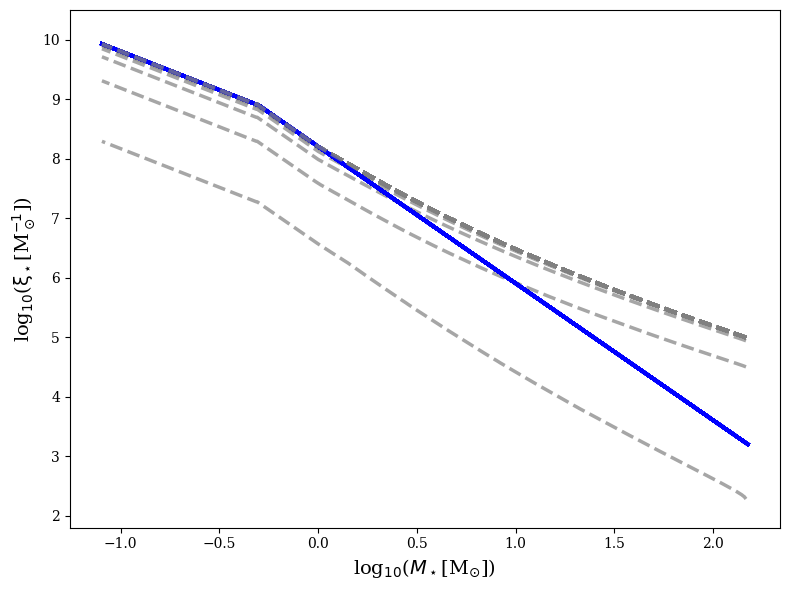

/var/folders/lk/c2m271qd50l6mrf8zrg8tgbw0000gp/T/ipykernel_73645/439666437.py:97: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(mass_list), np.log10(xi_Kroupa), '-', color='blue', alpha=0.7, linewidth=2.5)
/var/folders/lk/c2m271qd50l6mrf8zrg8tgbw0000gp/T/ipykernel_73645/439666437.py:101: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(mass_list), np.log10(xi_each_time), '--', color='grey', alpha=0.7, linewidth=2.5)
/var/folders/lk/c2m271qd50l6mrf8zrg8tgbw0000gp/T/ipykernel_73645/439666437.py:108: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(0, 1), loc="upper left", fontsize=10, frameon=False)


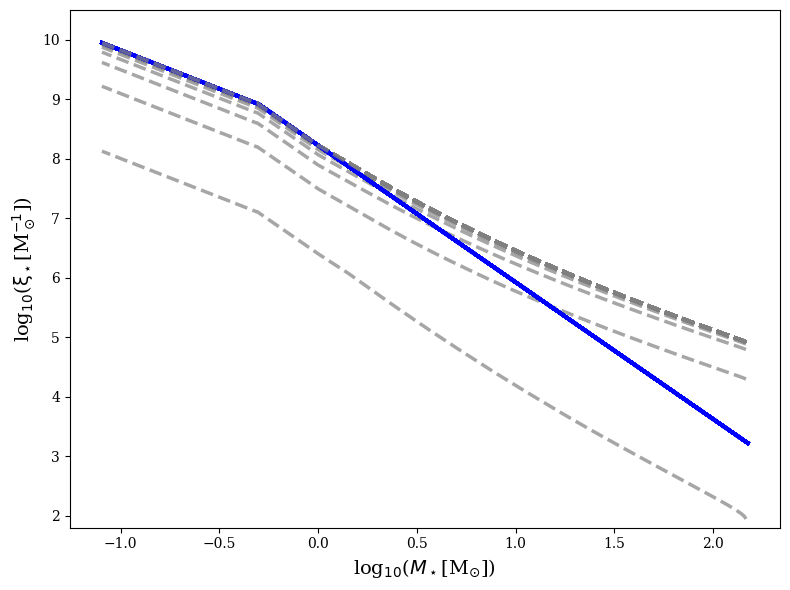

In [44]:
# Model 4, N13
plot_imf_files("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/paper/nomoto/igimf2/imfigimfSTF-4.15alpha2.3log_SFR<module 'igimf_SFR_-365447_Fe_over_H_1908581' from '/Users/adriana_work/Desktop/galIMF/Generated_IGIMFs/igimf_SFR_-365447_Fe_over_H_1908581.py'>SFEN1.0SFE0.008Z_0100infall0.0065/plots/", './paper/imf_evolution_n13.pdf')
# Model 2, LC18
# plot_imf_files("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/20260703/LCR300/igimf2/imfigimfSTF-4.15alpha2.3log_SFR<module 'igimf_SFR_-348282_Fe_over_H_1300417' from '/Users/adriana_work/Desktop/galIMF/Generated_IGIMFs/igimf_SFR_-348282_Fe_over_H_1300417.py'>SFEN1.0SFE0.007Z_0100infall0.008/plots/", 'imf_evolution_lc18.pdf')
plot_imf_files("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/20260703/LCR300/igimf2/imfigimfSTF-4.15alpha2.3log_SFR<module 'igimf_SFR_-364935_Fe_over_H_1628694' from '/Users/adriana_work/Desktop/galIMF/Generated_IGIMFs/igimf_SFR_-364935_Fe_over_H_1628694.py'>SFEN1.0SFE0.007Z_0100infall0.008/plots/", './paper/imf_evolution_lc18.pdf')